In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

events = pd.read_csv("events.csv")


In [2]:
events.isnull().sum()


event_id             0
user_id              0
event_name           0
event_description    0
event_type           0
location             0
event_image          0
start_date           0
end_date             0
created_at           0
updated_at           0
dtype: int64

In [3]:
events = events.dropna(subset=['created_at'])


In [4]:
events['created_at'] = pd.to_datetime(events['created_at'], errors='coerce')


In [5]:
events = events.dropna(subset=['created_at'])


In [6]:
events_per_day = events.groupby(events['created_at'].dt.date).size()
events_per_day.index = pd.to_datetime(events_per_day.index)


Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1203 ticks ([19304.0, ..., 20506.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to genera

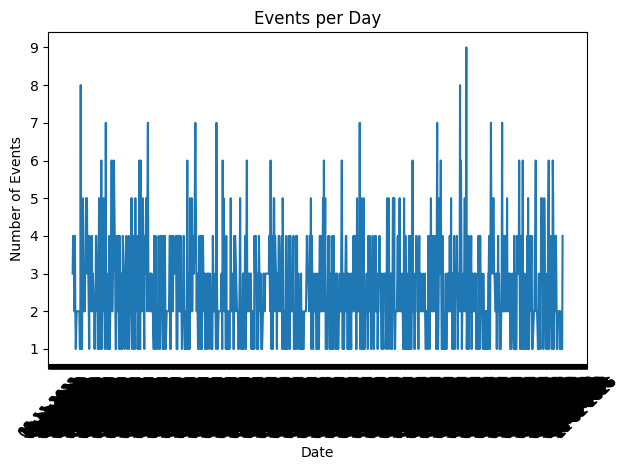

In [7]:
plt.figure()

plt.plot(events_per_day)

plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.title("Events per Day")

# X-axis: each day
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Date format: DD-MM-YYYY
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
events = events.dropna(subset=['event_type'])


In [9]:
events['event_type'] = events['event_type'].str.lower().str.strip()


In [10]:
top_event_types = events['event_type'].value_counts()


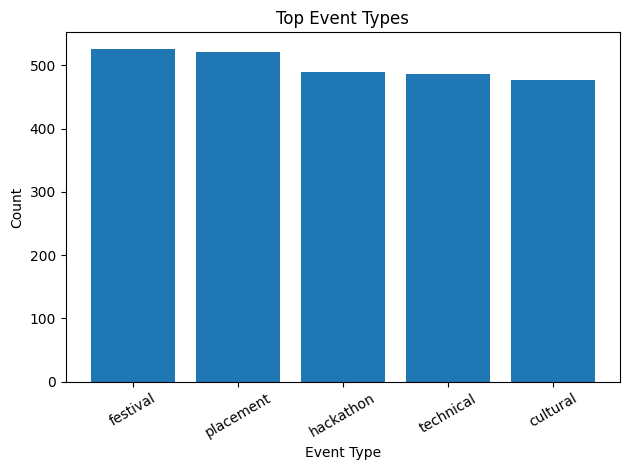

In [11]:
plt.figure()

plt.bar(top_event_types.index, top_event_types.values)

plt.xlabel("Event Type")
plt.ylabel("Count")
plt.title("Top Event Types")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
